# Week 2: Dataset Structuring and Validation

This notebook focuses on validating the residential listing and sold datasets generated in Week 1.

Main objectives:

- Review dataset structure and schema
- Compare listing and sold fields
- Identify duplicate columns
- Analyze missing values
- Flag high-missing columns
- Check duplicate records
- Generate numeric summaries
- Conduct percentile analysis
- Visualize key distributions
## Part 1: Load Combined Residential Datasets

In this section, we load the aggregated residential datasets from Week 1 and inspect their basic structure.

## Part 2: Dataset Preview

Preview the first few rows to understand how the data is structured.

In [14]:
# --------------------------------------------------
# Week 2: Dataset Structuring and Validation
# Part 1: Load combined datasets and inspect structure
# --------------------------------------------------

import pandas as pd

# Load Week 1 output files directly
listings = pd.read_csv(
    "../outputs/combined_listings_residential.csv",
    low_memory=False
)

sold = pd.read_csv(
    "../outputs/combined_sold_residential.csv",
    low_memory=False
)

# Check dataset shape
print("Listings shape:", listings.shape)
print("Sold shape:", sold.shape)

# Preview first 5 rows
print("\nListings preview:")
print(listings.head())

print("\nSold preview:")
print(sold.head())

# Check all column names
print("\nListing columns:")
print(listings.columns.tolist())

print("\nSold columns:")
print(sold.columns.tolist())

# Check data types
print("\nListing data types:")
print(listings.dtypes)

print("\nSold data types:")
print(sold.dtypes)

Listings shape: (591980, 84)
Sold shape: (433158, 82)

Listings preview:
   OriginalListPrice  ListingKey                        ListAgentEmail  \
0          1340000.0  1074973329                    haleh360@Gmail.com   
1          2500000.0  1074954552  Reneechen@yourhomesoldguaranteed.com   
2          3150000.0  1074936537                      anader@dppre.com   
3          3090000.0  1074917818                  QIANYU0607@GMAIL.COM   
4         12725000.0  1074143166          jeff.williams@pacificsir.com   

  CloseDate  ClosePrice ListAgentFirstName ListAgentLastName   Latitude  \
0       NaN         NaN              Haleh       Dowlatshahi  34.052207   
1       NaN         NaN              Renee              Chen  33.496363   
2       NaN         NaN           Margaret             Nader  34.119345   
3       NaN         NaN             QIANYU              GUAN  33.984057   
4       NaN         NaN               Jeff          Williams  33.607583   

    Longitude                Un

## Part 3: Schema Comparison

Compare the column structures between listing and sold datasets to identify differences.

In [15]:
# Find columns only in listings
listing_only = set(listings.columns) - set(sold.columns)

# Find columns only in sold
sold_only = set(sold.columns) - set(listings.columns)

print("Columns only in Listings:")
print(listing_only)

print("\nColumns only in Sold:")
print(sold_only)

Columns only in Listings:
{'UnparsedAddress.1', 'ListPrice.1', 'Latitude.1', 'LivingArea.1', 'PropertyType.1', 'DaysOnMarket.1', 'CloseDate.1', 'ListAgentLastName.1', 'BuyerOfficeName.1', 'ListAgentFirstName.1', 'Longitude.1'}

Columns only in Sold:
{'BasementYN', 'WaterfrontYN', 'Flooring', 'BuyerAgentAOR', 'PoolPrivateYN', 'OriginatingSystemName', 'ViewYN', 'ListAgentAOR', 'OriginatingSystemSubName'}



The schema comparison shows that the listing and sold datasets do not share identical structures.

Several listing-only columns appeared with a `.1` suffix, which suggests duplicated fields caused by certain `_filled` source files.

The sold dataset also contains several unique property-feature fields such as `BasementYN`, `WaterfrontYN`, and `PoolPrivateYN`, which may be useful for future segmentation analysis.

This step helps identify structural inconsistencies before further validation.

## Part 4: Duplicate Column Cleanup

Some listing files contain duplicate columns with ".1" suffixes. These are removed to maintain schema consistency.

In [16]:
# Find duplicate ".1" columns
duplicate_cols = [col for col in listings.columns if col.endswith('.1')]

print("Duplicate columns:")
print(duplicate_cols)

# Drop duplicate columns
listings = listings.drop(columns=duplicate_cols)

print("New Listings shape:", listings.shape)

Duplicate columns:
['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'CloseDate.1', 'BuyerOfficeName.1', 'UnparsedAddress.1']
New Listings shape: (591980, 73)




Duplicate columns with `.1` suffixes were removed from the listings dataset.

These duplicated fields were not meaningful additional variables, but repeated versions of existing columns.

Removing them improves schema consistency and prevents redundancy during future analysis.

## Part 5: Missing Value Analysis

Analyze missing values across all columns to evaluate data completeness.

In [17]:
# --------------------------------------------------
# Part 2: Missing Value Analysis
# --------------------------------------------------

# Count missing values
listing_missing_count = listings.isnull().sum()
sold_missing_count = sold.isnull().sum()

# Calculate missing percentages
listing_missing_pct = listings.isnull().mean() * 100
sold_missing_pct = sold.isnull().mean() * 100

# Create summary tables
listing_missing_summary = pd.DataFrame({
    "Missing Count": listing_missing_count,
    "Missing Percent": listing_missing_pct
}).sort_values("Missing Percent", ascending=False)

sold_missing_summary = pd.DataFrame({
    "Missing Count": sold_missing_count,
    "Missing Percent": sold_missing_pct
}).sort_values("Missing Percent", ascending=False)

# Top 20 missing columns
print("Top 20 Listing Missing Columns:")
print(listing_missing_summary.head(20))

print("\nTop 20 Sold Missing Columns:")
print(sold_missing_summary.head(20))

Top 20 Listing Missing Columns:
                              Missing Count  Missing Percent
MiddleOrJuniorSchoolDistrict         591980       100.000000
BusinessType                         591980       100.000000
TaxYear                              591980       100.000000
ElementarySchoolDistrict             591980       100.000000
TaxAnnualAmount                      591980       100.000000
AboveGradeFinishedArea               591980       100.000000
FireplacesTotal                      591980       100.000000
CoveredSpaces                        591980       100.000000
BelowGradeFinishedArea               588608        99.430386
CoBuyerAgentFirstName                577610        97.572553
BuilderName                          564621        95.378391
LotSizeDimensions                    560960        94.759958
BuildingAreaTotal                    539108        91.068617
ElementarySchool                     521435        88.083212
MiddleOrJuniorSchool                 521414        88



The missing value analysis shows that several fields have substantial incompleteness.

Most of the highest-missing fields are related to tax information, school districts, and optional property features.

This suggests that these variables may have limited analytical value or may require special handling during cleaning.

## Part 6: High Missing Fields (>90%)

Flag columns with more than 90% missing values for possible exclusion during data cleaning.

In [18]:
# --------------------------------------------------
# Part 3: Flag high-missing columns (>90%)
# --------------------------------------------------

# Listing columns with >90% missing
listing_high_missing = listing_missing_summary[
    listing_missing_summary["Missing Percent"] > 90
]

# Sold columns with >90% missing
sold_high_missing = sold_missing_summary[
    sold_missing_summary["Missing Percent"] > 90
]

print("Listing columns >90% missing:")
print(listing_high_missing)

print("\nSold columns >90% missing:")
print(sold_high_missing)

Listing columns >90% missing:
                              Missing Count  Missing Percent
MiddleOrJuniorSchoolDistrict         591980       100.000000
BusinessType                         591980       100.000000
TaxYear                              591980       100.000000
ElementarySchoolDistrict             591980       100.000000
TaxAnnualAmount                      591980       100.000000
AboveGradeFinishedArea               591980       100.000000
FireplacesTotal                      591980       100.000000
CoveredSpaces                        591980       100.000000
BelowGradeFinishedArea               588608        99.430386
CoBuyerAgentFirstName                577610        97.572553
BuilderName                          564621        95.378391
LotSizeDimensions                    560960        94.759958
BuildingAreaTotal                    539108        91.068617

Sold columns >90% missing:
                              Missing Count  Missing Percent
FireplacesTotal            



Fields with more than 90% missing values were flagged for review.

These variables are strong candidates for exclusion in later cleaning stages because they provide very limited usable information.

However, they are not removed at this stage in order to preserve the raw dataset structure.

## Part 7: Duplicate Record Analysis

Check for fully duplicated rows in both datasets.

In [ ]:
listing_duplicates = listings.duplicated().sum()
sold_duplicates = sold.duplicated().sum()

print("Listing duplicated rows:", listing_duplicates)
print("Sold duplicated rows:", sold_duplicates)

Listing duplicated rows: 0
Sold duplicated rows: 11493



Fields with more than 90% missing values were flagged for review.

These variables are strong candidates for exclusion in later cleaning stages because they provide very limited usable information.

However, they are not removed at this stage in order to preserve the raw dataset structure.

## Part 8: Duplicate Sold Record Inspection

Preview duplicated sold rows for further review.

In [20]:
# Show duplicate sold records
sold_duplicates_rows = sold[sold.duplicated()]

print(sold_duplicates_rows.head(10))
print("Duplicate rows shape:", sold_duplicates_rows.shape)

      BuyerAgentAOR ListAgentAOR         Flooring ViewYN WaterfrontYN  \
26987           NaN          NaN        Tile,Wood   True          NaN   
26988           NaN          NaN              NaN   True          NaN   
26989           NaN          NaN              NaN   True          NaN   
26990           NaN          NaN           Carpet  False          NaN   
26991           NaN          NaN              NaN  False          NaN   
26992           NaN          NaN              NaN   True          NaN   
26993           NaN          NaN              NaN  False          NaN   
26997           NaN          NaN              NaN   True          NaN   
26998           NaN          NaN        Tile,Wood  False          NaN   
27000           NaN          NaN  Carpet,Laminate   True          NaN   

      BasementYN PoolPrivateYN  OriginalListPrice  ListingKey  \
26987        NaN         False          1050000.0   535088655   
26988        NaN          True          3900000.0   530872071   
2


Inspection of duplicated sold records confirms that these rows are full-row duplicates rather than partial overlaps.

This suggests that duplicate removal can likely be performed safely in later cleaning stages.

## Part 9: Core Numeric Summary

Generate summary statistics for key market variables.

In [ ]:


numeric_cols = [
    'ClosePrice',
    'OriginalListPrice',
    'LivingArea',
    'DaysOnMarket',
    'BedroomsTotal',
    'BathroomsTotalInteger'
]

print(sold[numeric_cols].describe())

         ClosePrice  OriginalListPrice    LivingArea   DaysOnMarket  \
count  4.331560e+05       4.323580e+05  4.329160e+05  433158.000000   
mean   1.193831e+06       1.224866e+06  1.904411e+03      37.178143   
std    6.155159e+06       6.545302e+06  2.588656e+04      53.594665   
min    0.000000e+00       0.000000e+00  0.000000e+00    -288.000000   
25%    5.750000e+05       5.850000e+05  1.248000e+03       8.000000   
50%    8.250000e+05       8.288880e+05  1.645000e+03      18.000000   
75%    1.300000e+06       1.299000e+06  2.222000e+03      48.000000   
max    9.895000e+08       1.390000e+09  1.702132e+07   12430.000000   

       BedroomsTotal  BathroomsTotalInteger  
count  433146.000000          433086.000000  
mean        3.203606               2.536600  
std         1.066448               1.101637  
min         0.000000               0.000000  
25%         3.000000               2.000000  
50%         3.000000               2.000000  
75%         4.000000               3.0


The numeric summary reveals several data quality issues.

Close price and original list price both contain zero values and extremely large outliers.

Living area also includes unrealistic maximum values, while Days on Market contains negative values.

These findings indicate the need for outlier handling and validation in future cleaning stages.

## Part 10: Percentile Analysis

Use percentile summaries to identify extreme outliers.

In [ ]:


for col in numeric_cols:
    print(f"\nPercentiles for {col}:")
    print(
        sold[col].describe(
            percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        )
    )


Percentiles for ClosePrice:
count    4.331560e+05
mean     1.193831e+06
std      6.155159e+06
min      0.000000e+00
1%       2.032750e+05
5%       3.400000e+05
25%      5.750000e+05
50%      8.250000e+05
75%      1.300000e+06
95%      2.860000e+06
99%      5.567099e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

Percentiles for OriginalListPrice:
count    4.323580e+05
mean     1.224866e+06
std      6.545302e+06
min      0.000000e+00
1%       2.120000e+05
5%       3.499000e+05
25%      5.850000e+05
50%      8.288880e+05
75%      1.299000e+06
95%      2.900000e+06
99%      5.995000e+06
max      1.390000e+09
Name: OriginalListPrice, dtype: float64

Percentiles for LivingArea:
count    4.329160e+05
mean     1.904411e+03
std      2.588656e+04
min      0.000000e+00
1%       6.050000e+02
5%       8.400000e+02
25%      1.248000e+03
50%      1.645000e+03
75%      2.222000e+03
95%      3.562000e+03
99%      5.297000e+03
max      1.702132e+07
Name: LivingArea, dtype: float64

Percent



Percentile analysis provides a clearer view of the normal market range.

For example, the 99th percentile of close price is far lower than the maximum value, confirming the presence of extreme outliers.

This step helps distinguish typical market behavior from abnormal records.

## Part 11: Distribution Visualization

Visualize the typical distributions of key variables using the 1st to 99th percentile range.

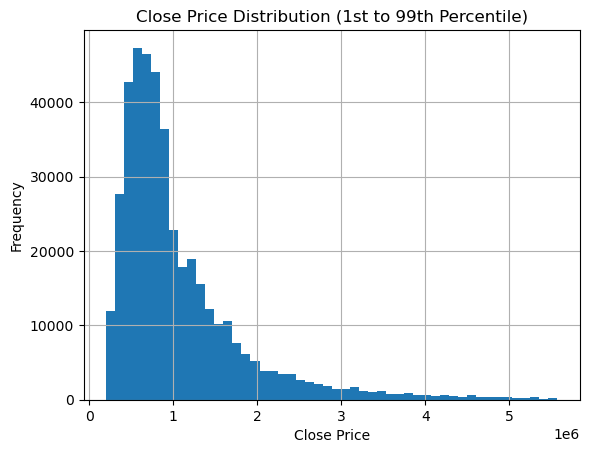

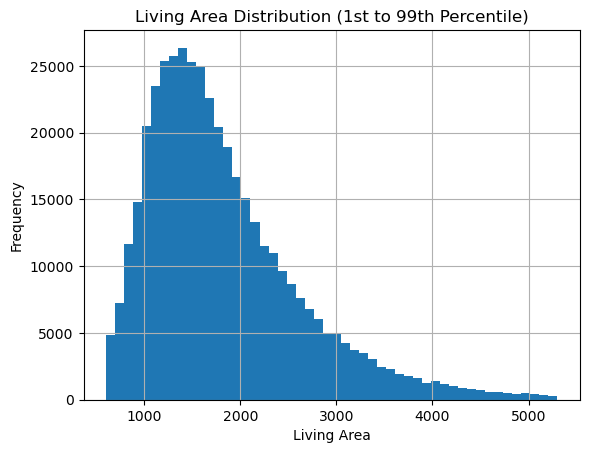

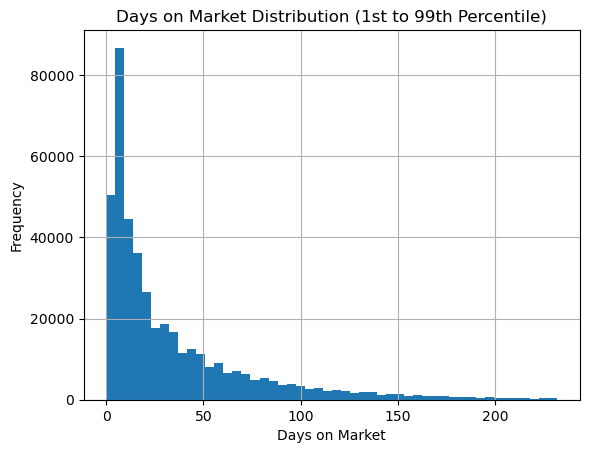

In [23]:
import matplotlib.pyplot as plt

# ClosePrice: zoom in to 1% - 99%
close_filtered = sold[
    (sold["ClosePrice"] >= sold["ClosePrice"].quantile(0.01)) &
    (sold["ClosePrice"] <= sold["ClosePrice"].quantile(0.99))
]

close_filtered["ClosePrice"].hist(bins=50)
plt.title("Close Price Distribution (1st to 99th Percentile)")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()


# LivingArea: zoom in to 1% - 99%
area_filtered = sold[
    (sold["LivingArea"] >= sold["LivingArea"].quantile(0.01)) &
    (sold["LivingArea"] <= sold["LivingArea"].quantile(0.99))
]

area_filtered["LivingArea"].hist(bins=50)
plt.title("Living Area Distribution (1st to 99th Percentile)")
plt.xlabel("Living Area")
plt.ylabel("Frequency")
plt.show()


# DaysOnMarket: zoom in to 1% - 99%
dom_filtered = sold[
    (sold["DaysOnMarket"] >= sold["DaysOnMarket"].quantile(0.01)) &
    (sold["DaysOnMarket"] <= sold["DaysOnMarket"].quantile(0.99))
]

dom_filtered["DaysOnMarket"].hist(bins=50)
plt.title("Days on Market Distribution (1st to 99th Percentile)")
plt.xlabel("Days on Market")
plt.ylabel("Frequency")
plt.show()


Percentile analysis provides a clearer view of the normal market range.

For example, the 99th percentile of close price is far lower than the maximum value, confirming the presence of extreme outliers.

This step helps distinguish typical market behavior from abnormal records.